In [12]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import norm, cauchy #theory fit

# NSL EXERCISES 01
## Parallel random number generator test and Buffon's experiment


Gabriele Borroni (14768A)



---
# Computing statistical extimators: the data blocking method

The average value of a quantity $\langle x \rangle$ and the uncertainty on its calculation $\sigma^2_x$ are crucial statistical quantities in Monte Carlo methods.
A wide-used method to calculate them in a way that reduces the correlation between data samples is the **data blocking technique**. 

The idea is to split the set of N samples of an observable x into M subsets (**blocks**) of size $L=\frac{N}{M}$ and to compute mean value $\langle x_i \rangle$ and the mean of the squared values $\langle x^2_i \rangle$ on each block first:
$$
\langle x_i \rangle=\frac{1}{L} \sum_{j=0}^{L-1}x_{iL+j} \quad \langle x_i^2 \rangle=\frac{1}{L} \sum_{j=0}^{L-1}x_{iL+j}^2
$$

These quantities are then **averaged over the blocks**, giving out the final expectation value and an uncorrelated estimation of the error:
$$
\langle x \rangle=\frac{1}{M} \sum_{j=1}^{M}\langle x_j \rangle \quad \langle x^2 \rangle=\frac{1}{M} \sum_{j=1}^{M}x_{j}^2
$$
$$
\sigma_x^2= \langle x^2 \rangle - (\langle x \rangle)^2
$$

In the first part of exercise 1, this method has been used to test the random number generator given to us students during the lab.

## Exercise 1.1 - test of the RNG

To check the validity of the given random number generator, it is possible to rely on the statistical properties that it must present, if it's well-built. For uniform random number $r \in [0,1)$, the generator's sequence must satisfy:

1. $\langle r \rangle = \int_0^1 r dr = 1/2$


2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$

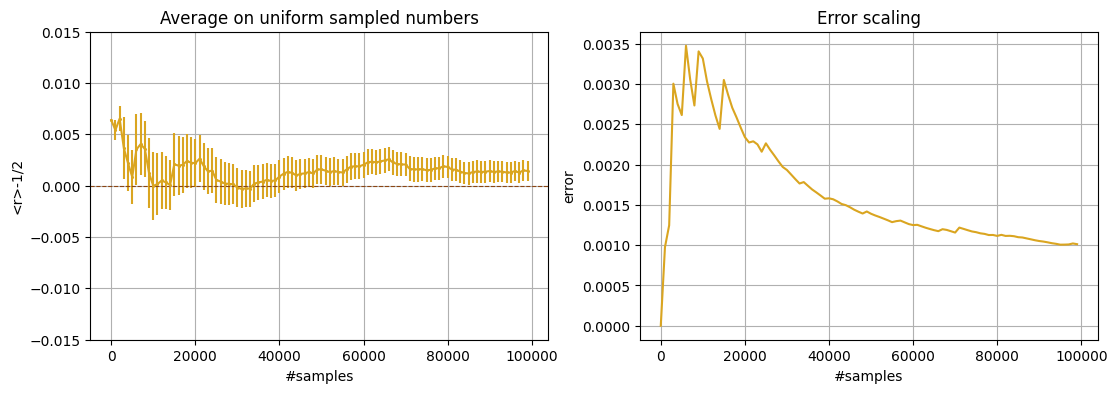

In [7]:

def plot_data_err(ax, x,y, ylabel, title, errorbar=False, err=None):
    if errorbar is True:
        ax.errorbar(x,y,yerr=err, fmt='-o', ms=1.2, color='goldenrod')
    else:
        ax.plot(x,y, color='goldenrod')
    ax.set_xlabel("#samples")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)

    
data=np.loadtxt('1.1/OUTPUT/RGtestAV.dat')          #format: block average || error
y=data[:,1]-0.5
err=data[:,2]
N=data.shape[0]                          #Number of blocks
M=100000                                 #Total samples
L=int(M/N)                               #Block length

x = np.arange(N)                         #[0,1,2,...,N-1]
x*=L
fig, ax=plt.subplots(1,2, figsize=(13,4))
ax=ax.flatten()
plot_data_err(ax[0], x, y, "<r>-1/2", "Average on uniform sampled numbers", True, err)
ax[0].set_ylim(-0.015, 0.015)
ax[0].axhline(0.0, ls='--', lw=0.8, color='saddlebrown')
plot_data_err(ax[1], x, err, "error", "Error scaling", False)



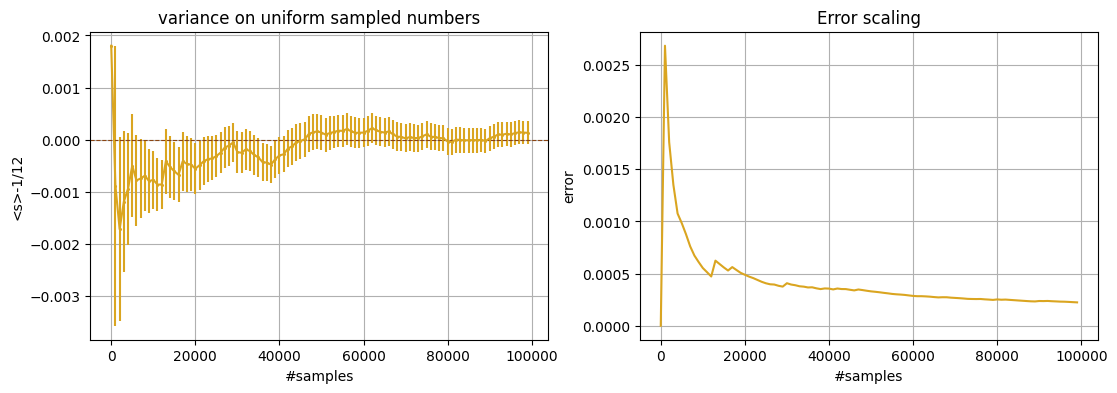

In [8]:
data=np.loadtxt('1.1/OUTPUT/RGtestSIGMA2.dat')
y=data[:,1]-1/12
err=data[:,2]

fig, ax=plt.subplots(1,2, figsize=(13,4))
ax=ax.flatten()
plot_data_err(ax[0], x, y, "<s>-1/12", "variance on uniform sampled numbers", True, err)
ax[0].axhline(0.0, ls='--', lw=0.8, color='saddlebrown')
plot_data_err(ax[1], x, err, "error", "Error scaling", False)

---
## Pearson test

It's impossible to prove wether a set of random numbers sampled with a deterministic generator comes from a given probability distribution or not. The **pearson $\chi^2$ test** is used to evaluate the probability that a set of number isn't sampled from a specific PDF, and if that probability is low enough, it's safe to assume that those samples actually come from a specific distribution. The pearson test consists in evaluating the error between the sampled value $O_i$ and the expected value $E_i$ sampled from the PDF:
$$
\chi^2=\sum_i \frac{(O_i-E_i)^2}{E_i}
$$

If the hypotesis is that the numbers are sampled from an uniform distribution, it's possible to approximate the expected values with the binomial distribution:
$$Pr(X=k) = {{n}\choose{k}} p^k (1-p)^{n-k} = \frac{n!}{k! (n-k)!} p^k (1-p)^{n-k}$$
The average of the Binomial distribution is $\langle X \rangle = np$, the variance is: $\sigma^2 = np (1-p)$. Thus if $p$ is small we have that $\sigma^2 \simeq np$, that is $\sigma^2 \simeq \langle X \rangle=E_i$ 

The test was computed by dividing [0,1) into m equally-spaced subintervals, so that $p=\frac{1}{m}\rightarrow E_i=\frac{n}{m}$.
$N=10^4$ random numbers are then drawn from the generator, and the number of samples ending up in each subinterval is accounted, in order to prepare the histogram below.


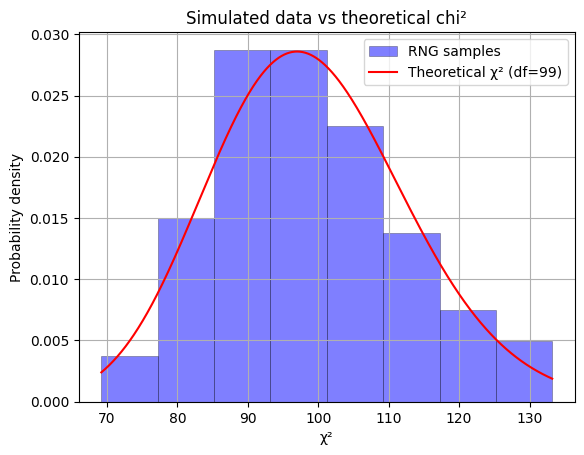

 <chi^2> 98.78560000000002


In [13]:
#1.1.3
chi_i=np.loadtxt('1.1/OUTPUT/chi2.dat')
plt.hist(chi_i, bins='auto', density=True, color='blue', alpha=0.5, edgecolor='black', linewidth=0.4, label='RNG samples')
#theoretical chi2 with 99GDL
M=100
df = M - 1
num_tests = 1000
x = np.linspace(min(chi_i), max(chi_i), 1000)
plt.plot(x, stats.chi2.pdf(x, df), 'r-', label=f'Theoretical χ² (df={df})')
plt.xlabel('χ²')
plt.ylabel('Probability density')
plt.title('Simulated data vs theoretical chi²')
plt.legend()
plt.grid(True)
plt.show()
print(f" <chi^2>",chi_i.mean())


---
# Exercise 1.2- central limit theorem check
##The central limit theorem


consider \( N \) statistically independent and identically distributed random variables $( x_1, x_2, \dots, x_N )$, i.e.,

$$
p_N(x_1, x_2, \dots, x_N) = p(x_1)p(x_2)\cdots p(x_N)
$$

which satisfy:

$$
\langle x_1 \rangle = \cdots = \langle x_N \rangle = \mu
\quad\text{and}\quad
\langle x_1^2 \rangle - \langle x_1 \rangle^2 = \cdots = \langle x_N^2 \rangle - \langle x_N \rangle^2 = \sigma^2 < \infty
$$

Define:

$$
A_N = \frac{1}{N} \sum_{n=1}^N x_n
\quad\text{and}\quad
S_N = \sum_{n=1}^N x_n
$$

Then:

1. **Expectation values**:
   $$
   \langle A_N \rangle = \mu
   \qquad
   \langle S_N \rangle = \mu N
   $$

2. **Variances**:
   $$
   \sigma_{A_N}^2 = \frac{\sigma^2}{N}
   \qquad
   \sigma_{S_N}^2 = N \sigma^2
   $$

3. **Probability distributions:**
   $$
   p_N(A_N) \xrightarrow[N \to \infty]{} \frac{1}{\sqrt{2\pi \sigma_{A_N}^2}} \exp\left[ -\frac{(A_N - \mu)^2}{2\sigma_{A_N}^2} \right]
   $$

   $$
   p_N(S_N) \xrightarrow[N \to \infty]{} \frac{1}{\sqrt{2\pi \sigma_{S_N}^2}} \exp\left[ -\frac{(S_N - \mu N)^2}{2\sigma_{S_N}^2} \right]
   $$


 Regardless of the underlying distribution of the individual variables, as long as the first two moments exist, the **sum** and the **average** of the variables tend toward a **Gaussian distribution** as $ N \to \infty $.

 This theorem canbegeneralized to variables which are not identically distributed as long as all variables have finite variance; in this case the average tends to the average of the averages, and the variance tend to the average of the variances divided by N.

 Actually, the Gaussian distribution represent only one point in the infinite **basin of attraction**, the set of all possible attractors. A simple case in which the hypotesis aren't satisfied for the Gaussian, is the Lorentzian distribution, which itself is another attractor.

 In this exercise, it has been shown the effect of this theorem in both the cases of Gaussian and Lorentzian hypotesis. To do so, an "unfair dice" has been coded by extending the random number generatore as follows.

 ## From uniform to a desired distribution with the inverse of the cumulative

 The **cumulative function F(x)** of a given probability distribution p(x) is defined as:
 $$
 F(x)=\int_{-\infty}^{x}p(x')dx'
 $$
 The inverse of cumulative method consists in sampling a uniform random number $u\in[0,1)$ and then evaluating $F^{-1}(u)$, where F is the cumulative function of the probability distribution desired. It is possible to show that doing so the variables
 $$
 y=F^{-1}(u)
 $$
 follow the desired PDF.
 In the code, this approach has been implemented for two different kinds of PDFs:

 1.Exponential:

 $$
 F(x)=1-e^{-\lambda x} \Rightarrow F^{-1}(u)=-\frac{ln(1-u)}{\lambda}
 $$

2. Lorentzian:
 $$
 F(x) = \frac{1}{\pi} \arctan\left( \frac{x - \mu}{\Gamma} \right) + \frac{1}{2}
 \quad \Rightarrow \quad
 F^{-1}(u) = \mu + \Gamma \cdot \tan\left[ \pi (u - 0.5) \right]
 $$

Then, $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$) have been computed, being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, $\lambda=1$) and a *Lorentzian* dice (fig.3, $\mu=0$ and $\Gamma=1$) 



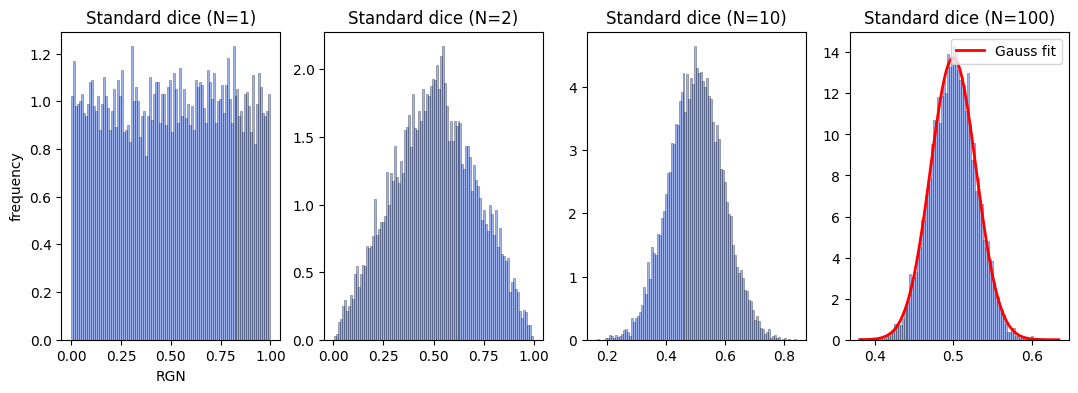

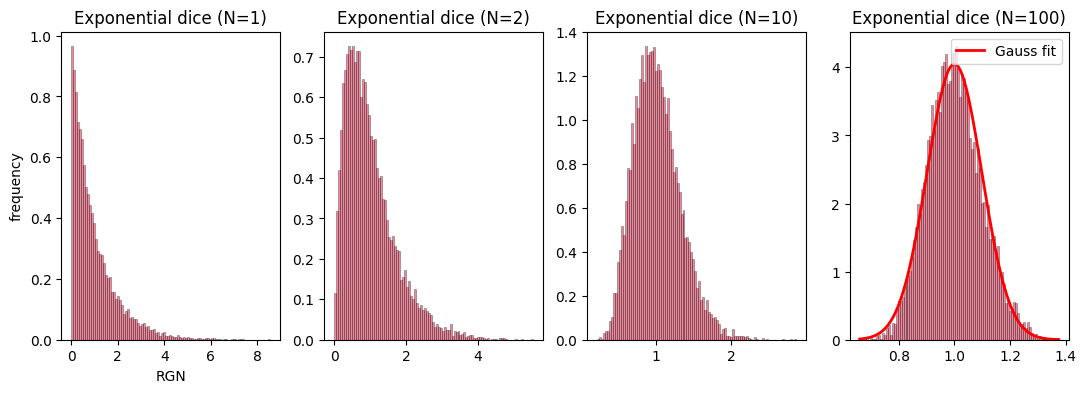

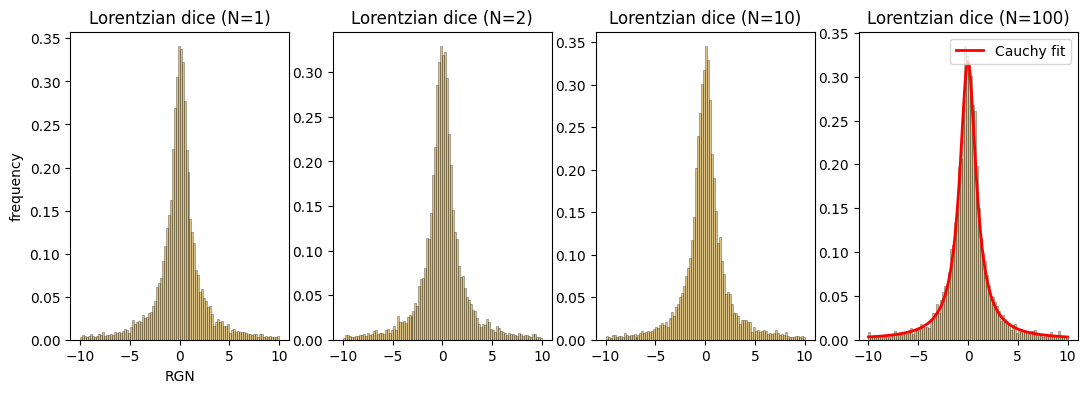

In [10]:
std = np.loadtxt("1.2/OUTPUT/Standard_dice.dat")
N = std[:, 0]
Ns = np.unique(N).astype(int)
block_size = int(len(N) / len(Ns))
bins = 100
fig, axes = plt.subplots(1, len(Ns), figsize=(13, 4))  
for i in range(len(Ns)):
    values = std[i * block_size : (i + 1) * block_size, 1]
    ax = axes[i]
    ax.hist(values, bins=bins, density=True, color='royalblue', alpha=0.5,edgecolor='black', linewidth=0.4)
    axes[0].set_xlabel("RGN")
    axes[0].set_ylabel("frequency")
    ax.set_title(f"Standard dice (N={Ns[i]})")
    mu_u, sigma_u = norm.fit(values) #calcola parametri per il fit
    x_u = np.linspace(min(values), max(values), 100)
axes[3].plot(x_u, norm.pdf(x_u, mu_u, sigma_u), 'r-', lw=2, label='Gauss fit')
axes[3].legend()

exp = np.loadtxt("1.2/OUTPUT/Exp_dice.dat")
fig, axes = plt.subplots(1, len(Ns), figsize=(13, 4))  
for i in range(len(Ns)):
    values = exp[i * block_size : (i + 1) * block_size, 1]
    ax = axes[i]
    ax.hist(values, bins=bins, density=True, color='crimson', alpha=0.5,edgecolor='black', linewidth=0.4)
    axes[0].set_xlabel("RGN")
    axes[0].set_ylabel("frequency")
    ax.set_title(f"Exponential dice (N={Ns[i]})")
    mu_e, sigma_e = norm.fit(values) #calcola parametri per il fit
    x_e = np.linspace(min(values), max(values), 100)
axes[3].plot(x_e, norm.pdf(x_e, mu_e, sigma_e), 'r-', lw=2, label='Gauss fit')
axes[3].legend()
lor = np.loadtxt("1.2/OUTPUT/Lorentzian_dice.dat")
fig, axes = plt.subplots(1, len(Ns), figsize=(13, 4))  
for i in range(len(Ns)):
    values = lor[i * block_size : (i + 1) * block_size, 1]
    ax = axes[i]
    ax.hist(values, bins=bins, range=(-10,10),density=True, color='darkgoldenrod', alpha=0.5,edgecolor='black', linewidth=0.4)
    axes[0].set_xlabel("RGN")
    axes[0].set_ylabel("frequency")
    ax.set_title(f"Lorentzian dice (N={Ns[i]})")
    params = cauchy.fit(values)
    x_c = np.linspace(-10, 10, 1000)
axes[3].plot(x_c, cauchy.pdf(x_c, *params), 'r-', lw=2, label='Cauchy fit')
axes[3].legend()    



From these results, it's safe to assume that the uniform and exponential distributions implemented meet the CLT hypotesis, and thus converge to a Gaussian distribution. On the other hand, for the Lorentzian dice the Gauss-CLT hypotesis don't hold, because $\sigma$ and $\mu$ are not finite. Cauchy-Lorentz is a great example of a **stable non-gaussian distribution**, and it is an attractor for other Cauchy-Lorentz distribution, in a similar way to the central limit theorem.


---
# Exercise 1.3: the Buffon's needle experiment

A needle of length $l$ is randomly thrown on a grid made up by parallel lines, all equally spaced by $d$. It is possible to show that the probability of the needle intercepting the lines is $P=\frac{2l}{\pi d}$. This gives out a way to compute $\pi$ by using a Monte Carlo approach: by trhowing $N_{tot}$ random number, and counting the $N_{hit}$ times in which the needles hit a line, one has:
$$
\pi=\lim_{N_{tot}\to \infty}\frac{2l N_{tot}}{d N_{hit}}
$$

The code implements this approach in three steps:

1. sample the midpoint position of the needle with a uniform random number $r\in(0, \frac{d}{2})$
2. sample 2 uniform random numbers $x,y \in (0,1)$ that represent the angular position of the needle
3.Check if the needle has hit the line with the condition:
$$
r\leq \frac{l}{2}\sin{\theta}=\frac{l}{2}|\frac{y}{x^2+y^2}|
$$
the final value of $ \pi $ is obtained again through the data blocking method, and the results ar shown below.

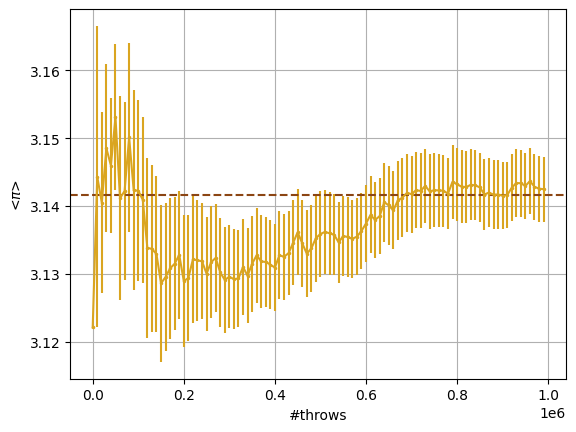

In [11]:
#1.3
data=np.loadtxt('1.3/OUTPUT/Buffon_experiment.dat')
M=1000000               # Total number of throws
N=data.shape[0]         # Number of blocks
L=int(M/N)              # Number of throws in each block, please use for M a multiple of N
x = np.arange(N)        # [0,1,2,...,N-1]
x*=L                    # Number of throws = block * (Number of throws in each block)
y=data[:,1]
err=data[:,2]
plt.errorbar(x,y,yerr=err, color='goldenrod', fmt='-o', ms=1.5)
plt.grid(True)
plt.xlabel('#throws')
plt.ylabel(r'<$\pi$>')
plt.axhline(y=np.pi, ls= '--', color='saddlebrown')




Given that:
1. Using a uniform distribution, the generator is able to sample numbers that show the same mean and variance to the theoretical uniform ditribution.
2. The numbers sampled with the inverse of the cumulative using the uniform numbers drawn from the generator match the central limit theorem predictions.
3. Numbers sampled with the generator give an accurate value of $\pi$ in the Buffon's experiment.

It's safe to assume that the parallel random number generator given is a "good one", and it is reliable to be used in future Monte-Carlo applications.